# Pizza Place Sales — Exploratory Data Analysis

**Files:** `orders.csv`, `order_details.csv`, `pizzas.xlsx`, `pizza_types.xlsx`

**A note on ordering:** the raw files turned out to have real data quality problems
(mixed date formats, `$` signs mixed into a numeric price column, inconsistent
category/size spellings, duplicate keys, orphaned foreign keys). Merging first and
cleaning after would let duplicate keys silently multiply rows during the join, and
would push text/type problems into every downstream step. So the order here is:

**Setup → Load → Profile each raw file → Clean each raw file → Merge → Inspect final
data → Univariate → Bivariate/Multivariate → Time-based → Visualization → Insights**


## 1. Project Setup

In [6]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Check Files

In [7]:
import os
files = [f for f in os.listdir('.') if f.endswith(('.csv', '.xlsx'))]
print(f"Data files found: {files}")

Data files found: ['orders.csv', 'order_details.csv', 'pizzas.xlsx', 'pizza_types.xlsx']


## 3. Load Files

In [8]:
orders        = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
pizzas        = pd.read_excel('pizzas.xlsx')
pizza_types   = pd.read_excel('pizza_types.xlsx')

print("orders:        ", orders.shape)
print("order_details: ", order_details.shape)
print("pizzas:        ", pizzas.shape)
print("pizza_types:   ", pizza_types.shape)

orders:         (85656, 3)
order_details:  (194966, 4)
pizzas:         (394, 4)
pizza_types:    (136, 4)


## 4. Preview Files & Identify Merge Keys

In [9]:
# Look at each table so the join keys and column meanings are clear before we touch anything
print("--- orders ---")
display(orders.head(4))

print("--- order_details ---")
display(order_details.head(4))

print("--- pizzas ---")
display(pizzas.head(4))

print("--- pizza_types ---")
display(pizza_types.head(4))

# Join plan:
#   order_details.order_id      -> orders.order_id
#   order_details.pizza_id      -> pizzas.pizza_id
#   pizzas.pizza_type_id        -> pizza_types.pizza_type_id


--- orders ---


,order_id,date,time
0,53143.0,2023-10-19,19:22:31
1,19912.0,2023-04-21,21:54:57
2,82571.0,2023-05-27,17:57:24
3,38004.0,2023-06-14,13:03:02


--- order_details ---


,order_detail_id,order_id,pizza_id,quantity
0,23179,27236,pz_0377,1.0
1,75465,51059,pz_0153,2.0
2,170029,81554,pz_0083,3.0
3,46582,20574,pz_0206,3.0


--- pizzas ---


,pizza_id,pizza_type_id,size,price
0,pz_0290,pt_050,XL,21.59
1,pz_0281,pt_056,M,$14.41
2,pz_0106,pt_093,s,$8.13
3,pz_0003,pt_075,XL,20.05


--- pizza_types ---


,pizza_type_id,name,category,ingredients
0,pt_006,The Hawaiian Classic,Classic,"Arugula, Green Peppers, Garlic, Kalamata Olive..."
1,pt_109,The Prosciutto Classic,Supreme,"Anchovies, Truffle Oil, Kalamata Olives, Gouda..."
2,pt_100,The Bacon Classic,Veggie,"Chipotle Sauce, Green Peppers, Smoked Salmon"
3,pt_066,The Mediterranean Feast,Veggie,"Barbecue Sauce, Prosciutto, Thyme"


## 5. Data Quality Profiling (raw files)

Profiling each table *before* touching it, so every cleaning decision below is
backed by an actual number rather than a guess.

In [5]:
def profile(df, name):
    print(f"\n=== {name} ===  shape={df.shape}")
    print("dtypes:\n", df.dtypes)
    print("\nmissing values:\n", df.isnull().sum())
    print("\nfull duplicate rows:", df.duplicated().sum())

profile(orders, "orders")
profile(order_details, "order_details")
profile(pizzas, "pizzas")
profile(pizza_types, "pizza_types")


=== orders ===  shape=(85656, 3)
dtypes:
 order_id    float64
date            str
time            str
dtype: object

missing values:
 order_id       0
date        1286
time        1712
dtype: int64

full duplicate rows: 256

=== order_details ===  shape=(194966, 4)
dtypes:
 order_detail_id      int64
order_id             int64
pizza_id               str
quantity           float64
dtype: object

missing values:
 order_detail_id       0
order_id              0
pizza_id           1562
quantity           2340
dtype: int64

full duplicate rows: 486

=== pizzas ===  shape=(394, 4)
dtypes:
 pizza_id            str
pizza_type_id       str
size                str
price            object
dtype: object

missing values:
 pizza_id          0
pizza_type_id     0
size              0
price            12
dtype: int64

full duplicate rows: 6

=== pizza_types ===  shape=(136, 4)
dtypes:
 pizza_type_id    str
name             str
category         str
ingredients      str
dtype: object

missing values:
 p

In [6]:
# orders: duplicate order_id + date format consistency check
print("Duplicate order_id count:", orders['order_id'].duplicated().sum())
print("Sample date strings:", orders['date'].dropna().unique()[:10])
print("Literal '0000-00-00' placeholder dates:", (orders['date'] == '0000-00-00').sum())


Duplicate order_id count: 256
Sample date strings: <StringArray>
['2023-10-19', '2023-04-21', '2023-05-27', '2023-06-14', '2023-01-27', '2023-02-07', '2023-12-19', '2023-01-23',
 '2023-11-07', '2023-08-24']
Length: 10, dtype: str
Literal '0000-00-00' placeholder dates: 3


In [7]:
# order_details: key integrity + quantity sanity check
print("Duplicate pizza_id count in pizzas table:", pizzas['pizza_id'].duplicated().sum())
print("order_details.quantity describe:\n", order_details['quantity'].describe())
print("Negative/zero quantity rows:", (order_details['quantity'] <= 0).sum())
print("order_id in order_details but missing from orders:",
      (~order_details['order_id'].isin(orders['order_id'])).sum())
print("pizza_id in order_details but missing from pizzas:",
      (~order_details['pizza_id'].isin(pizzas['pizza_id'])).sum())


Duplicate pizza_id count in pizzas table: 6
order_details.quantity describe:
 count    192626.000000
mean          1.651937
std           1.018249
min          -3.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         100.000000
Name: quantity, dtype: float64
Negative/zero quantity rows: 8
order_id in order_details but missing from orders: 15


pizza_id in order_details but missing from pizzas: 1577


In [8]:
# pizzas: price column type + size spelling consistency
print("pizzas['size'] raw unique values:", sorted(pizzas['size'].dropna().unique()))
print("\npizzas['price'] dtype issue -- mixed numbers and '$'-prefixed strings:")
print(pizzas['price'].apply(type).value_counts())
print("\npizza_type_id in pizzas but missing from pizza_types:",
      (~pizzas['pizza_type_id'].isin(pizza_types['pizza_type_id'])).sum())


pizzas['size'] raw unique values: [' M', 'L', 'M', 'S', 'XL', 'XXL', 'Xl', 'l ', 's']

pizzas['price'] dtype issue -- mixed numbers and '$'-prefixed strings:
price
<class 'float'>    366
<class 'str'>       24
<class 'int'>        4
Name: count, dtype: int64

pizza_type_id in pizzas but missing from pizza_types: 5


In [9]:
# pizza_types: category spelling consistency
print("pizza_types['category'] raw unique values:")
print(sorted(pizza_types['category'].dropna().unique()))
print("\nDuplicate pizza_type_id count:", pizza_types['pizza_type_id'].duplicated().sum())


pizza_types['category'] raw unique values:
['CHICKEN', 'Chicken', 'Chickken', 'Clasic', 'Classic', 'Classic ', 'Suprem', 'Supreme', 'VEGGIE', 'Veggei', 'Veggie', 'Veggie ', 'chicken', 'supreme']

Duplicate pizza_type_id count: 4


**Findings summary**

| Table | Issue |
|---|---|
| `orders` | 256 full duplicate rows; `date` mixes 4 formats (`YYYY-MM-DD`, `DD-MM-YYYY`, `MM/DD/YYYY`, `MM/DD/YY`) plus `0000-00-00` placeholders and 1,286 blanks; `time` has 1,712 blanks |
| `order_details` | 486 duplicate rows; `pizza_id` missing in 1,562 rows; `quantity` missing in 2,340 rows, negative in 8 rows; some `order_id`/`pizza_id` values don't exist in their parent tables |
| `pizzas` | 6 duplicate `pizza_id`; `price` mixes numeric and `"$14.41"`-style strings, 12 blanks; `size` has 9 spelling/case variants (`XL`, `Xl`, `s`, `' M'`, `'l '`...) that should collapse to 5 |
| `pizza_types` | 4 duplicate `pizza_type_id`; `category` has 14 spelling/case variants that should collapse to 4 (`Classic`, `Supreme`, `Veggie`, `Chicken`); a few blank `name`/`ingredients` |


## 6. Data Cleaning (per table, before merging)

In [10]:
# ---- Clean: pizza_types -----------------------------------------------------
pizza_types_clean = pizza_types.copy()

# Drop duplicate pizza_type_id, keep first occurrence
pizza_types_clean = pizza_types_clean.drop_duplicates(subset='pizza_type_id', keep='first')

# Standardize category: trim whitespace, fix case, correct known typos
category_fix = {'suprem': 'supreme', 'veggei': 'veggie', 'clasic': 'classic', 'chickken': 'chicken'}
pizza_types_clean['category'] = (
    pizza_types_clean['category'].str.strip().str.lower()
    .replace(category_fix)
    .str.title()
)

# Fill blank text fields rather than drop -- category-level analysis doesn't need them
pizza_types_clean['name'] = pizza_types_clean['name'].fillna('Unknown')
pizza_types_clean['ingredients'] = pizza_types_clean['ingredients'].fillna('Not specified')

print("category values after cleaning:", sorted(pizza_types_clean['category'].unique()))
print("pizza_types_clean shape:", pizza_types_clean.shape)


category values after cleaning: ['Chicken', 'Classic', 'Supreme', 'Veggie']
pizza_types_clean shape: (132, 4)


In [11]:
# ---- Clean: pizzas -----------------------------------------------------------
pizzas_clean = pizzas.copy()

# Drop duplicate pizza_id
pizzas_clean = pizzas_clean.drop_duplicates(subset='pizza_id', keep='first')

# price: strip '$' if present, cast everything to float
pizzas_clean['price'] = (
    pizzas_clean['price'].astype(str).str.replace('$', '', regex=False).astype(float)
)

# Impute the 12 blank prices using the median price for that pizza's size
# (a size-based median is a much better estimate than the overall median)
pizzas_clean['price'] = pizzas_clean.groupby('size')['price'].transform(
    lambda s: s.fillna(s.median())
)

# size: trim + uppercase collapses ALL 9 raw variants down to 5 clean labels
pizzas_clean['size'] = pizzas_clean['size'].str.strip().str.upper()

# Drop rows whose pizza_type_id doesn't exist in the cleaned pizza_types table
# (can't be assigned a category/name, so unusable downstream)
pizzas_clean = pizzas_clean[pizzas_clean['pizza_type_id'].isin(pizza_types_clean['pizza_type_id'])]

print("size values after cleaning:", sorted(pizzas_clean['size'].unique()))
print("remaining blank prices:", pizzas_clean['price'].isnull().sum())
print("pizzas_clean shape:", pizzas_clean.shape)


size values after cleaning: ['L', 'M', 'S', 'XL', 'XXL']
remaining blank prices: 0
pizzas_clean shape: (383, 4)


In [12]:
# ---- Clean: orders -------------------------------------------------------
orders_clean = orders.copy()

# Drop full duplicate rows
orders_clean = orders_clean.drop_duplicates()

def parse_mixed_date(value):
    """orders['date'] mixes 4 formats plus '0000-00-00' placeholders -- try each in turn."""
    if pd.isna(value) or value == '0000-00-00':
        return pd.NaT
    for fmt in ('%Y-%m-%d', '%d-%m-%Y', '%m/%d/%Y', '%m/%d/%y'):
        try:
            return datetime.strptime(value, fmt)
        except ValueError:
            continue
    return pd.NaT

orders_clean['order_date'] = orders_clean['date'].apply(parse_mixed_date)
orders_clean['order_time'] = pd.to_datetime(orders_clean['time'], format='%H:%M:%S', errors='coerce').dt.time
orders_clean['order_id'] = orders_clean['order_id'].astype('Int64')

# order_date is the core time dimension for this analysis -- drop rows where
# it couldn't be recovered at all. order_time gaps are kept as null (less critical).
before = len(orders_clean)
orders_clean = orders_clean.dropna(subset=['order_date'])
print(f"Dropped {before - len(orders_clean)} rows with unrecoverable order_date")

orders_clean = orders_clean.drop(columns=['date', 'time'])
print("orders_clean shape:", orders_clean.shape)
print("order_date range:", orders_clean['order_date'].min(), "to", orders_clean['order_date'].max())


Dropped 1290 rows with unrecoverable order_date
orders_clean shape: (84110, 3)
order_date range: 1900-01-01 00:00:00 to 2099-01-01 00:00:00


In [13]:
# ---- Clean: order_details -------------------------------------------------
order_details_clean = order_details.copy()

# Drop full duplicate rows
order_details_clean = order_details_clean.drop_duplicates()

# Both pizza_id and quantity are essential to compute revenue per line --
# rows missing either can't be used
order_details_clean = order_details_clean.dropna(subset=['pizza_id', 'quantity'])

# Negative/zero quantity is a data-entry error for this business (no returns table exists)
order_details_clean = order_details_clean[order_details_clean['quantity'] > 0]

# Note: max quantity of 100 is kept as a plausible bulk/catering order, not treated
# as an error -- flagged here for visibility, not removed
print("Orders with quantity >= 20 (bulk orders, kept):",
      (order_details_clean['quantity'] >= 20).sum())

order_details_clean['quantity'] = order_details_clean['quantity'].astype(int)

# Drop rows referencing an order_id or pizza_id that no longer exists
# after the cleaning above (orphaned foreign keys)
order_details_clean = order_details_clean[
    order_details_clean['order_id'].isin(orders_clean['order_id']) &
    order_details_clean['pizza_id'].isin(pizzas_clean['pizza_id'])
]

print("order_details_clean shape:", order_details_clean.shape)


Orders with quantity >= 20 (bulk orders, kept): 20
order_details_clean shape: (185127, 4)


## 7. Merge Cleaned Tables

In [14]:
df = order_details_clean.merge(orders_clean, on='order_id', how='inner')
print("after merging orders:       ", df.shape)

df = df.merge(pizzas_clean, on='pizza_id', how='inner')
print("after merging pizzas:       ", df.shape)

df = df.merge(pizza_types_clean, on='pizza_type_id', how='inner')
print("after merging pizza_types:  ", df.shape)

# Row count should grow roughly linearly with each join, not explode --
# a sudden jump would signal a duplicate-key fan-out we missed
df['line_total'] = df['quantity'] * df['price']
df.head()


after merging orders:        (185127, 6)
after merging pizzas:        (185127, 9)
after merging pizza_types:   (185127, 12)


,order_detail_id,order_id,pizza_id,quantity,order_date,order_time,pizza_type_id,size,price,name,category,ingredients,line_total
0,23179,27236,pz_0377,1,2023-03-03,14:38:41,pt_048,M,12.21,The Greek Classic,Supreme,"Tomatoes, Duck, Spinach, Artichokes",12.21
1,75465,51059,pz_0153,2,2023-05-14,13:14:58,pt_084,XL,20.74,The Smoked Salmon Special,Veggie,"Pepperoni, Chicken, Capers, Smoked Salmon, Chi...",41.48
2,170029,81554,pz_0083,3,2023-04-23,21:55:46,pt_126,XL,20.76,The BBQ Delight,Classic,"Duck, Corn, Sun-dried Tomatoes, Pepperoni, Pin...",62.28
3,46582,20574,pz_0206,3,2023-09-23,20:51:55,pt_013,S,9.86,The Chipotle Supreme,Chicken,"Spinach, Artichokes, Feta Cheese, Chicken, Cor...",29.58
4,185978,73574,pz_0041,1,2023-09-04,19:52:24,pt_062,L,15.04,The Calabrese Pizza,Supreme,"Artichokes, Arugula, Blue Cheese, Pineapple, C...",15.04


## 8. Initial Inspection (final analysis-ready dataset)

In [15]:
print("Shape:", df.shape)
print()
df.info()


Shape: (185127, 13)



<class 'pandas.DataFrame'>
RangeIndex: 185127 entries, 0 to 185126
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_detail_id  185127 non-null  int64         
 1   order_id         185127 non-null  int64         
 2   pizza_id         185127 non-null  str           
 3   quantity         185127 non-null  int64         
 4   order_date       185127 non-null  datetime64[us]
 5   order_time       181273 non-null  object        
 6   pizza_type_id    185127 non-null  str           
 7   size             185127 non-null  str           
 8   price            185127 non-null  float64       
 9   name             185127 non-null  str           
 10  category         185127 non-null  str           
 11  ingredients      185127 non-null  str           
 12  line_total       185127 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(3), object(1), str(6)
memory usage: 18.4+ MB


In [16]:
df.describe(include='number')


,order_detail_id,order_id,quantity,price,line_total
count,185127.000000,185127.000000,185127.000000,185127.000000,185127.000000
mean,97195.666186,42658.919715,1.651396,18.398998,30.318799
std,56144.036627,24613.162752,1.023894,22.360629,46.799169
min,1.000000,1.000000,1.000000,-5.500000,-22.000000
25%,48540.500000,21321.000000,1.000000,11.950000,14.670000
50%,97212.000000,42654.000000,1.000000,14.990000,22.100000
75%,145819.500000,63968.000000,2.000000,20.960000,34.140000
max,194480.000000,85400.000000,100.000000,300.000000,6599.670000


In [17]:
df.describe(include='object')


,pizza_id,order_time,pizza_type_id,size,name,category,ingredients
count,185127,181273,185127,185127,185127,185127,185127
unique,383,32861,132,5,130,4,126
top,pz_0085,21:00:14,pt_004,S,Unknown,Veggie,Not specified
freq,533,31,2490,39635,3903,53672,11654


## 9. Univariate Analysis

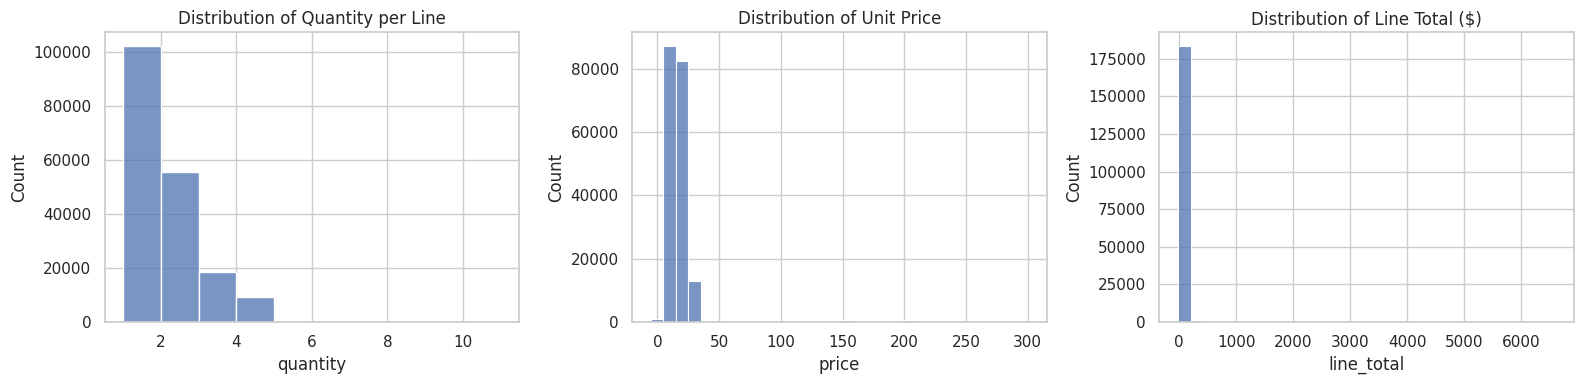

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['quantity'], bins=range(1, 12), ax=axes[0])
axes[0].set_title('Distribution of Quantity per Line')
sns.histplot(df['price'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Unit Price')
sns.histplot(df['line_total'], bins=30, ax=axes[2])
axes[2].set_title('Distribution of Line Total ($)')
plt.tight_layout()
plt.show()


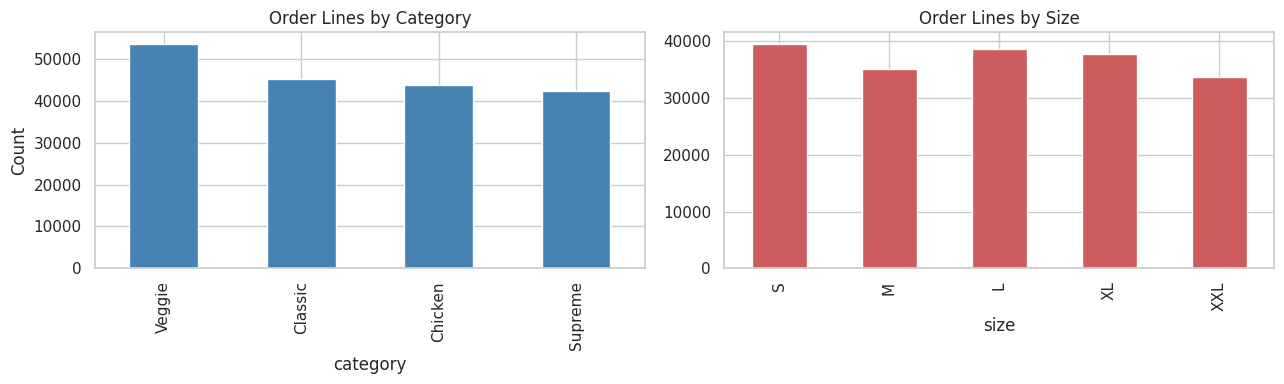

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Order Lines by Category')
axes[0].set_ylabel('Count')

size_order = ['S', 'M', 'L', 'XL', 'XXL']
df['size'].value_counts().reindex(size_order).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Order Lines by Size')
plt.tight_layout()
plt.show()


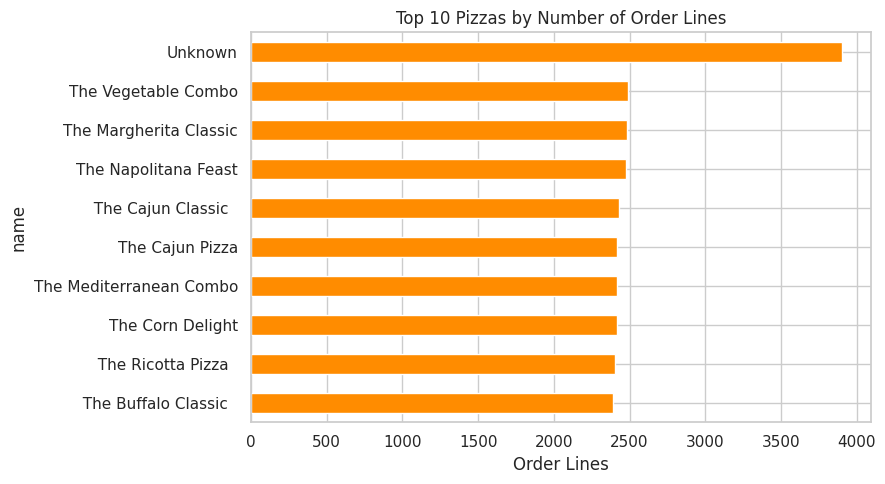

In [20]:
top_pizzas = df['name'].value_counts().head(10)
plt.figure(figsize=(9, 5))
top_pizzas.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 10 Pizzas by Number of Order Lines')
plt.xlabel('Order Lines')
plt.tight_layout()
plt.show()


## 10. Bivariate / Multivariate Analysis

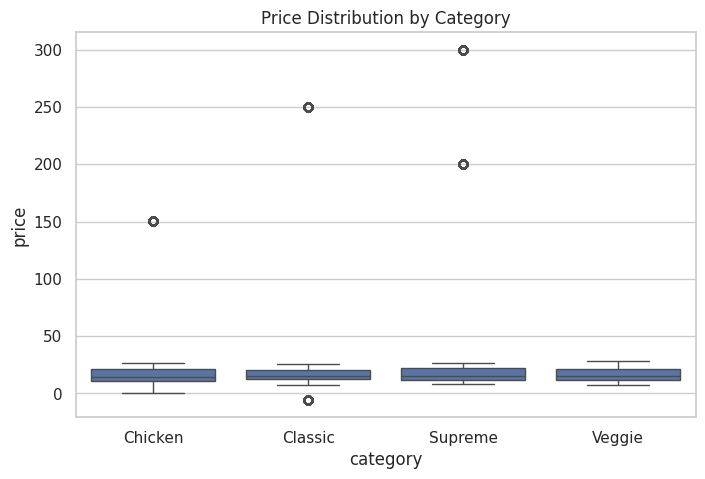

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='category', y='price', order=sorted(df['category'].unique()))
plt.title('Price Distribution by Category')
plt.show()


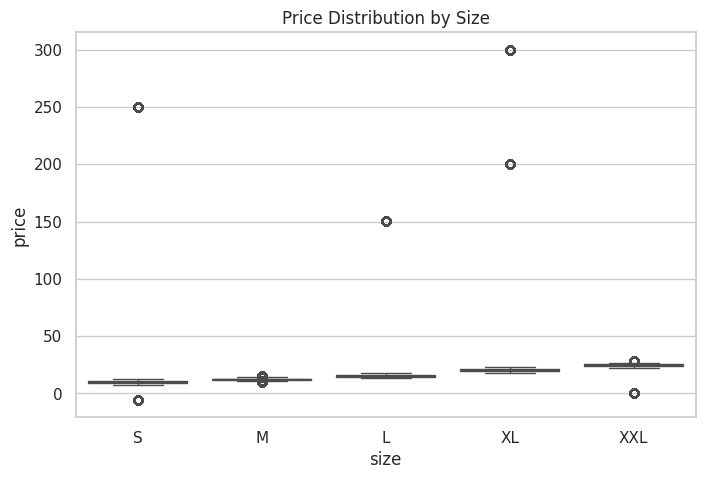

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='size', y='price', order=size_order)
plt.title('Price Distribution by Size')
plt.show()


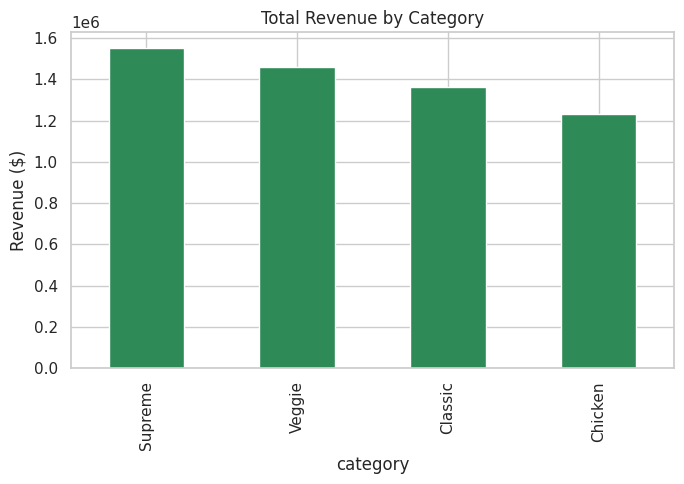

category
Supreme    1551036.69
Veggie     1462611.83
Classic    1365774.03
Chicken    1233405.71
Name: line_total, dtype: float64

In [23]:
revenue_by_category = df.groupby('category')['line_total'].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
revenue_by_category.plot(kind='bar', color='seagreen')
plt.title('Total Revenue by Category')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()
revenue_by_category


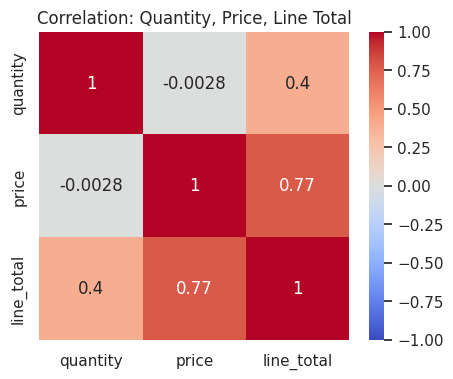

In [24]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[['quantity', 'price', 'line_total']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Quantity, Price, Line Total')
plt.show()


In [25]:
pd.crosstab(df['category'], df['size'])


size,L,M,S,XL,XXL
category,,,,,
Chicken,8170,9626,11099,8230,6714
Classic,11639,7876,9041,10366,6325
Supreme,8245,6606,8716,9138,9664
Veggie,10668,11110,10779,10026,11089


## 11. Time-Based Analysis

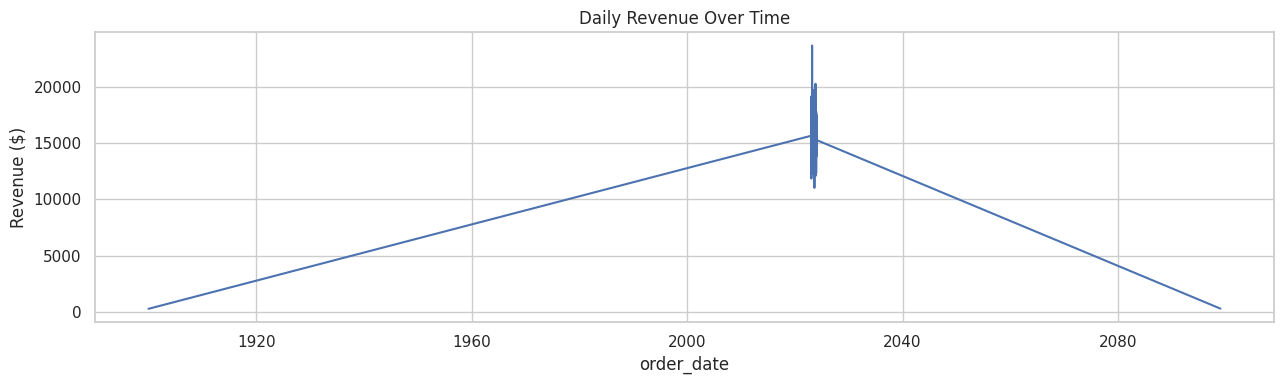

In [26]:
daily = df.groupby(df['order_date'].dt.date)['line_total'].sum()
plt.figure(figsize=(13, 4))
daily.plot()
plt.title('Daily Revenue Over Time')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()


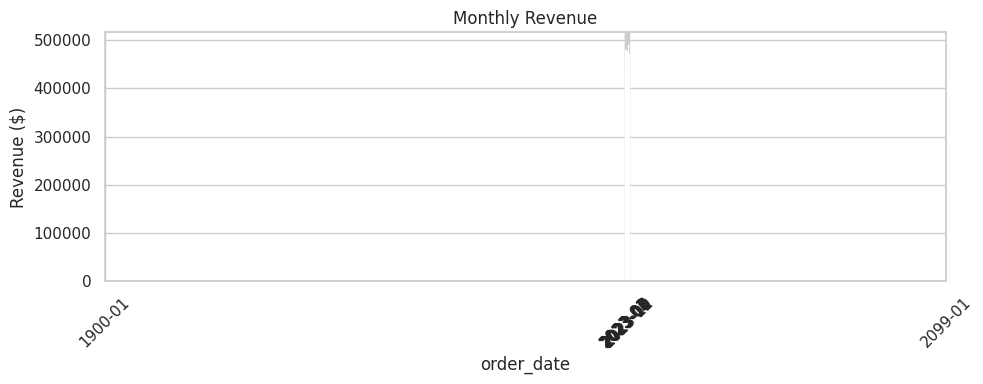

In [27]:
monthly = df.groupby(df['order_date'].dt.to_period('M'))['line_total'].sum()
plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='mediumpurple')
plt.title('Monthly Revenue')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


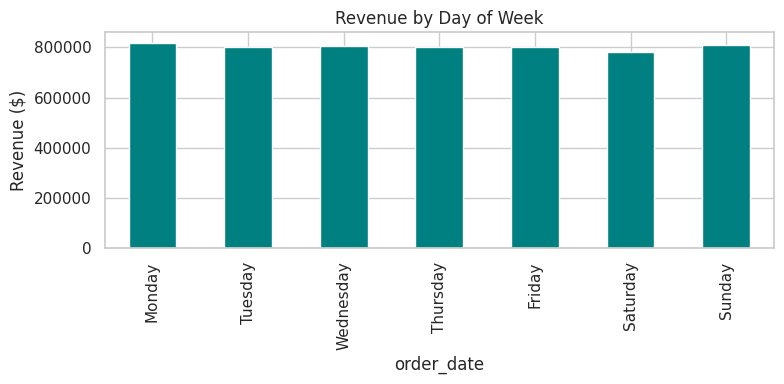

In [28]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_dow = df.groupby(df['order_date'].dt.day_name())['line_total'].sum().reindex(dow_order)
plt.figure(figsize=(8, 4))
by_dow.plot(kind='bar', color='teal')
plt.title('Revenue by Day of Week')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()


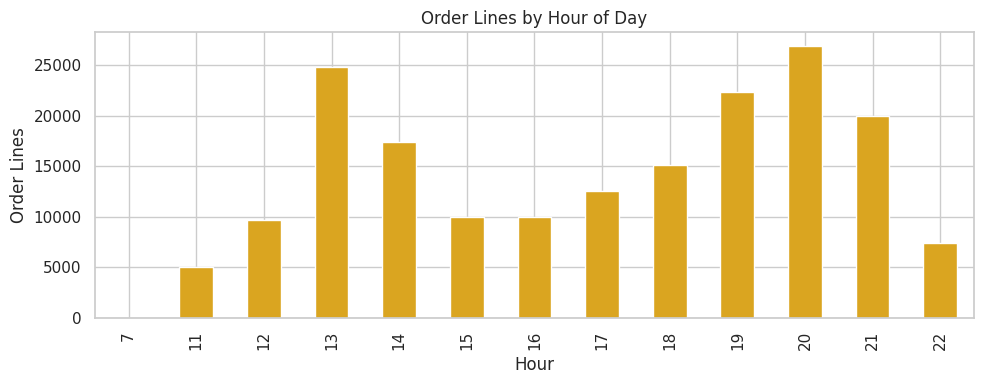

In [29]:
# Hour-of-day pattern (peak ordering times) -- uses order_time where available
hours = df['order_time'].dropna().apply(lambda t: t.hour)
plt.figure(figsize=(10, 4))
hours.value_counts().sort_index().plot(kind='bar', color='goldenrod')
plt.title('Order Lines by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Order Lines')
plt.tight_layout()
plt.show()


## 12. Visualization — Key Story Charts

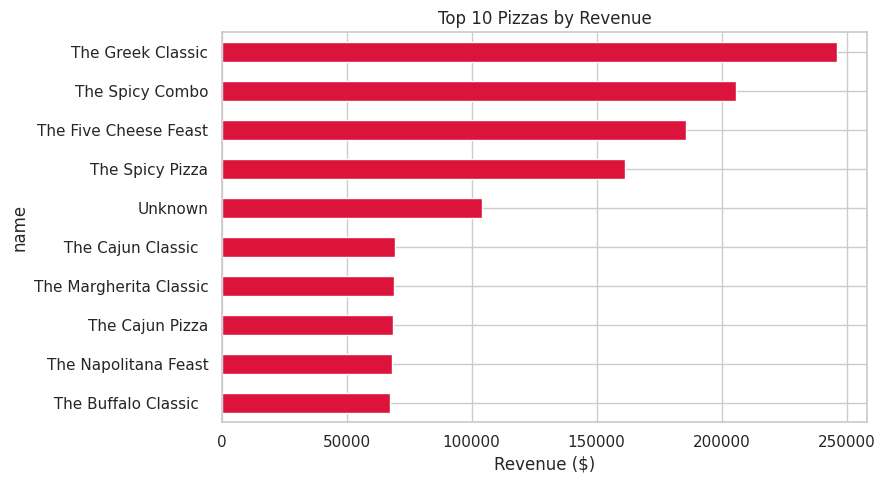

In [30]:
top10_revenue = df.groupby('name')['line_total'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5))
top10_revenue.sort_values().plot(kind='barh', color='crimson')
plt.title('Top 10 Pizzas by Revenue')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()


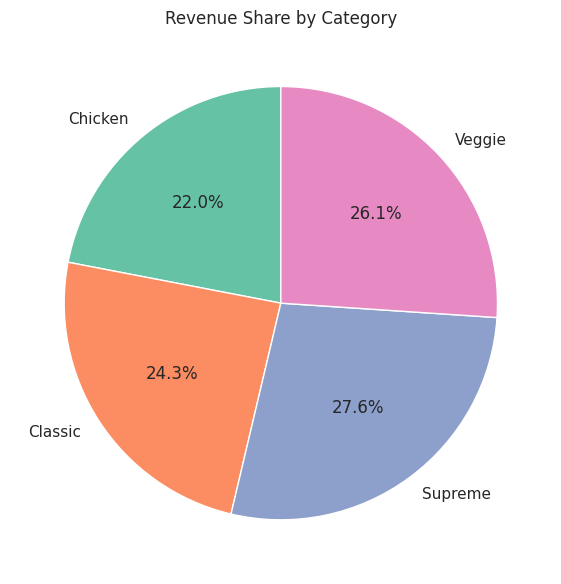

In [31]:
share = df.groupby('category')['line_total'].sum()
plt.figure(figsize=(6, 6))
plt.pie(share, labels=share.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Set2'))
plt.title('Revenue Share by Category')
plt.tight_layout()
plt.show()


## 13. Insights & Reporting

In [32]:
total_revenue   = df['line_total'].sum()
total_orders    = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
top_category    = revenue_by_category.idxmax()
top_pizza       = top10_revenue.idxmax()
best_day        = by_dow.idxmax()
peak_hour       = hours.value_counts().idxmax()

print(f"Total revenue:            ${total_revenue:,.2f}")
print(f"Total distinct orders:    {total_orders:,}")
print(f"Average order value:      ${avg_order_value:,.2f}")
print(f"Top category by revenue:  {top_category}")
print(f"Top pizza by revenue:     {top_pizza}")
print(f"Best day of week:         {best_day}")
print(f"Peak ordering hour:       {peak_hour}:00")


Total revenue:            $5,612,828.26
Total distinct orders:    74,846
Average order value:      $74.99
Top category by revenue:  Supreme
Top pizza by revenue:     The Greek Classic
Best day of week:         Monday
Peak ordering hour:       20:00


**Executive summary**

- The KPIs above are the headline numbers to lead a report with: total revenue,
  order volume, and average order value.
- `category` and `size` distributions (Section 9) show which segments dominate
  order volume — worth comparing against the revenue-by-category chart (Section
  10) to check whether high-volume categories are also high-revenue, or whether
  a smaller category is quietly punching above its weight per order.
- The daily/monthly trend (Section 11) is where to look for growth, seasonality,
  or a specific bad week worth investigating further.
- Day-of-week and hour-of-day patterns are directly actionable for staffing and
  inventory planning.
- **Data caveats to disclose in any report using this analysis:** rows with
  unrecoverable dates, missing pizza/quantity references, or orphaned foreign
  keys were dropped during cleaning (see Section 6 for exact counts) — the
  cleaned dataset is a subset of the raw files, not a 1:1 match.

**Natural next steps:** customer/order-size segmentation, a repeat-vs-one-time
order split (would need a customer identifier, which this dataset doesn't have),
or a basic forecast of next month's revenue from the monthly trend.
